In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

# Load model and data
xgb_tuned     = pickle.load(open('models/xgb_tuned.pkl', 'rb'))
scaler        = pickle.load(open('models/scaler.pkl', 'rb'))
feature_names = pickle.load(open('models/feature_names.pkl', 'rb'))
THRESHOLD     = pickle.load(open('models/threshold.pkl', 'rb'))

# Reload and re-process the FULL original dataset
# (We need MonthlyCharges + tenure for CLV — they were scaled away)
df_raw = pd.read_csv('data/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df_raw['TotalCharges'] = pd.to_numeric(df_raw['TotalCharges'], errors='coerce')
df_raw.dropna(subset=['TotalCharges'], inplace=True)
df_raw['Churn'] = df_raw['Churn'].map({'Yes': 1, 'No': 0})

# Load test set predictions
X_test = pd.read_csv('data/X_test.csv')
y_test = pd.read_csv('data/y_test.csv').values.ravel()

# Get churn probabilities
y_prob  = xgb_tuned.predict_proba(X_test)[:, 1]
y_pred  = (y_prob >= THRESHOLD).astype(int)

print(f"Test set size         : {len(y_test):,} customers")
print(f"Predicted churners    : {y_pred.sum():,} ({y_pred.mean()*100:.1f}%)")
print(f"Actual churners       : {y_test.sum():,} ({y_test.mean()*100:.1f}%)")

Test set size         : 1,407 customers
Predicted churners    : 483 (34.3%)
Actual churners       : 374 (26.6%)


In [2]:
# Align the raw dataframe to test set indices
# The test set is 20% of 7032 rows = 1406 rows
# We need to recover the original MonthlyCharges + tenure for those customers

# Re-run the train/test split with same random_state to recover test indices
from sklearn.model_selection import train_test_split

df_processed = df_raw.copy()
df_processed.drop(columns=['customerID'], inplace=True)

# Rebuild binary + encoded columns minimally to get same split
df_processed['Churn_target'] = df_processed['Churn']

_, df_test_raw = train_test_split(
    df_processed,
    test_size=0.2,
    random_state=42,
    stratify=df_processed['Churn']
)

df_test_raw = df_test_raw.reset_index(drop=True)

# Build the revenue dataframe
revenue_df = pd.DataFrame({
    'churn_probability' : y_prob,
    'predicted_churn'   : y_pred,
    'actual_churn'      : y_test,
    'monthly_charges'   : df_test_raw['MonthlyCharges'].values,
    'tenure'            : df_test_raw['tenure'].values,
    'contract'          : df_test_raw['Contract'].values,
})

# CLV = Monthly Charges × Average Expected Remaining Tenure
# Average remaining tenure depends on contract type
avg_remaining_tenure = {
    'Month-to-month' : 12,   # conservative — 1 year if retained
    'One year'       : 18,
    'Two year'       : 30
}

revenue_df['avg_remaining_tenure'] = revenue_df['contract'].map(avg_remaining_tenure)

# CLV formula
revenue_df['clv'] = (revenue_df['monthly_charges'] * 
                     revenue_df['avg_remaining_tenure'])

print("\nCLV Summary:")
print(revenue_df['clv'].describe().round(2))
print(f"\nAverage CLV: ${revenue_df['clv'].mean():,.0f}")
print(f"Max CLV    : ${revenue_df['clv'].max():,.0f}")


CLV Summary:
count    1407.00
mean     1092.93
std       725.92
min       226.20
25%       599.70
50%       926.10
75%      1267.65
max      3562.50
Name: clv, dtype: float64

Average CLV: $1,093
Max CLV    : $3,562


In [3]:
# Filter to predicted churners only
at_risk_df = revenue_df[revenue_df['predicted_churn'] == 1].copy()

total_revenue_at_risk    = at_risk_df['clv'].sum()
monthly_revenue_at_risk  = at_risk_df['monthly_charges'].sum()
num_at_risk              = len(at_risk_df)
avg_clv_at_risk          = at_risk_df['clv'].mean()

print("=" * 50)
print("REVENUE AT RISK SUMMARY")
print("=" * 50)
print(f"Customers flagged as at-risk  : {num_at_risk:,}")
print(f"Monthly revenue at risk       : ${monthly_revenue_at_risk:,.0f}")
print(f"Total CLV at risk             : ${total_revenue_at_risk:,.0f}")
print(f"Average CLV per at-risk cust. : ${avg_clv_at_risk:,.0f}")
print()
print(f"💡 Headline insight: The model has identified")
print(f"   ${monthly_revenue_at_risk:,.0f}/month in at-risk revenue")
print(f"   across {num_at_risk} customers.")

REVENUE AT RISK SUMMARY
Customers flagged as at-risk  : 483
Monthly revenue at risk       : $35,123
Total CLV at risk             : $435,940
Average CLV per at-risk cust. : $903

💡 Headline insight: The model has identified
   $35,123/month in at-risk revenue
   across 483 customers.


In [4]:
# Define segments based on churn probability and CLV
clv_median  = revenue_df['clv'].median()
risk_cutoff = 0.5   # above = high risk

def segment(row):
    high_risk  = row['churn_probability'] >= risk_cutoff
    high_value = row['clv'] >= clv_median
    if high_risk and high_value:
        return 'High Risk\nHigh Value'
    elif high_risk and not high_value:
        return 'High Risk\nLow Value'
    elif not high_risk and high_value:
        return 'Low Risk\nHigh Value'
    else:
        return 'Low Risk\nLow Value'

revenue_df['segment'] = revenue_df.apply(segment, axis=1)

segment_summary = revenue_df.groupby('segment').agg(
    Customers   = ('clv', 'count'),
    Total_CLV   = ('clv', 'sum'),
    Avg_CLV     = ('clv', 'mean'),
    Avg_Risk    = ('churn_probability', 'mean')
).round(0)

print("\nSEGMENT BREAKDOWN")
print(segment_summary.to_string())


SEGMENT BREAKDOWN
                       Customers  Total_CLV  Avg_CLV  Avg_Risk
segment                                                       
High Risk\nHigh Value        176   197178.0   1120.0       1.0
High Risk\nLow Value         183   124728.0    682.0       1.0
Low Risk\nHigh Value         528   931223.0   1764.0       0.0
Low Risk\nLow Value          520   284627.0    547.0       0.0


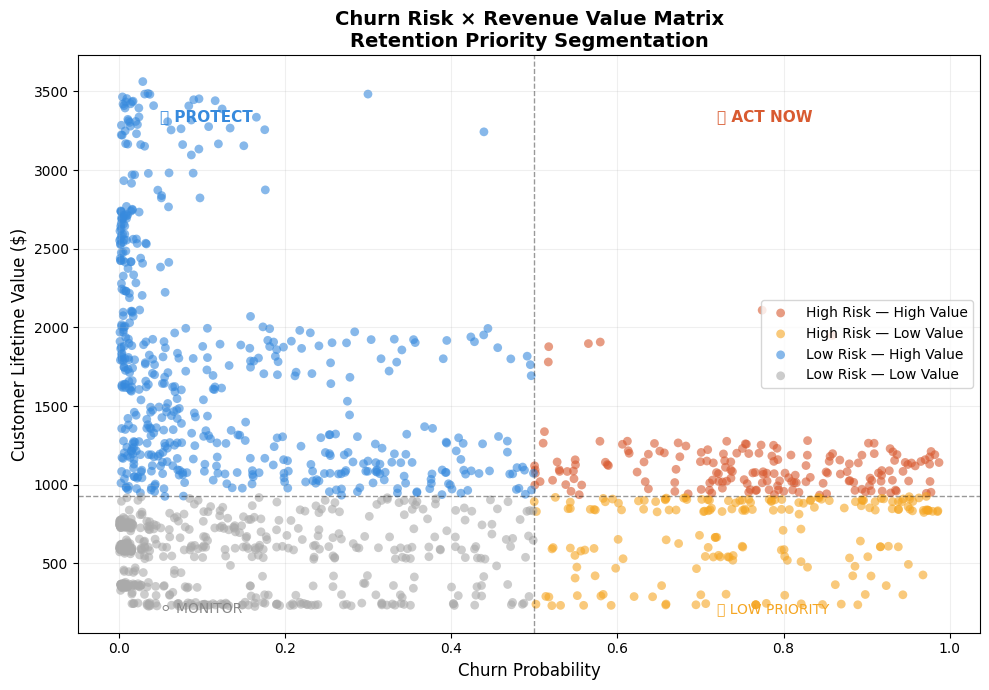

In [5]:
fig, ax = plt.subplots(figsize=(10, 7))

colors = {
    'High Risk\nHigh Value' : '#D85A30',
    'High Risk\nLow Value'  : '#F5A623',
    'Low Risk\nHigh Value'  : '#378ADD',
    'Low Risk\nLow Value'   : '#AAAAAA'
}

for segment_name, group in revenue_df.groupby('segment'):
    ax.scatter(
        group['churn_probability'],
        group['clv'],
        c=colors[segment_name],
        label=segment_name.replace('\n', ' — '),
        alpha=0.6,
        s=40,
        edgecolors='none'
    )

# Draw quadrant lines
ax.axvline(x=risk_cutoff,  color='black', linestyle='--', alpha=0.4, linewidth=1)
ax.axhline(y=clv_median,   color='black', linestyle='--', alpha=0.4, linewidth=1)

# Quadrant labels
ax.text(0.72, revenue_df['clv'].max()*0.93,
        '🔴 ACT NOW', fontsize=11, fontweight='bold', color='#D85A30')
ax.text(0.72, clv_median*0.2,
        '🟡 LOW PRIORITY', fontsize=10, color='#F5A623')
ax.text(0.05, revenue_df['clv'].max()*0.93,
        '🔵 PROTECT', fontsize=11, fontweight='bold', color='#378ADD')
ax.text(0.05, clv_median*0.2,
        '⚪ MONITOR', fontsize=10, color='#888888')

ax.set_xlabel('Churn Probability', fontsize=12)
ax.set_ylabel('Customer Lifetime Value ($)', fontsize=12)
ax.set_title('Churn Risk × Revenue Value Matrix\nRetention Priority Segmentation',
             fontsize=14, fontweight='bold')
ax.legend(loc='center right', fontsize=10)
ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig('charts/14_risk_value_matrix.png', dpi=150)
plt.show()

"The top-right quadrant — high risk, high value — is where the retention team should focus all their budget. These customers are likely to leave AND they're worth the most. The bottom-right is high risk but low value, so we don't spend much on them. The top-left are valuable customers who aren't going anywhere — we just protect them."


In [6]:
# Rank at-risk customers by CLV (highest value first)
at_risk_ranked = at_risk_df.sort_values('clv', ascending=False).copy()
at_risk_ranked['rank'] = range(1, len(at_risk_ranked) + 1)
at_risk_ranked['risk_level'] = pd.cut(
    at_risk_ranked['churn_probability'],
    bins=[0, 0.5, 0.7, 1.0],
    labels=['Medium', 'High', 'Critical']
)

top20 = at_risk_ranked.head(20)[[
    'rank', 'churn_probability', 'risk_level',
    'monthly_charges', 'clv', 'tenure', 'contract'
]].copy()

top20.columns = ['Rank', 'Churn Prob', 'Risk Level',
                 'Monthly $', 'CLV $', 'Tenure (mo)', 'Contract']
top20['Churn Prob'] = top20['Churn Prob'].map('{:.1%}'.format)
top20['Monthly $']  = top20['Monthly $'].map('${:,.0f}'.format)
top20['CLV $']      = top20['CLV $'].map('${:,.0f}'.format)

print("\nTOP 20 CUSTOMERS TO CONTACT — RANKED BY CLV AT RISK")
print(top20.to_string(index=False))

top20.to_csv('data/top20_at_risk_customers.csv', index=False)
print("\n✓ Saved to data/top20_at_risk_customers.csv")


TOP 20 CUSTOMERS TO CONTACT — RANKED BY CLV AT RISK
 Rank Churn Prob Risk Level Monthly $  CLV $  Tenure (mo) Contract
    1      43.9%     Medium      $108 $3,243           48 Two year
    2      77.4%   Critical      $117 $2,110           68 One year
    3      44.4%     Medium      $111 $1,994           62 One year
    4      43.9%     Medium      $108 $1,952           68 One year
    5      85.9%   Critical      $108 $1,949           42 One year
    6      42.4%     Medium      $108 $1,940           58 One year
    7      35.5%     Medium      $107 $1,922           51 One year
    8      39.5%     Medium      $106 $1,917           52 One year
    9      42.8%     Medium      $106 $1,909           44 One year
   10      57.9%       High      $106 $1,907           40 One year
   11      35.7%     Medium      $106 $1,904           40 One year
   12      56.5%       High      $105 $1,897           67 One year
   13      51.7%       High      $104 $1,877           43 One year
   14    

In [7]:
# Assumptions (realistic industry figures)
RETENTION_OFFER_COST     = 50     # $ discount or gift per customer contacted
RETENTION_SUCCESS_RATE   = 0.30   # 30% of at-risk customers accept & stay
CONTACT_TOP_N            = 200    # retention team can contact 200/month

# Select top N by CLV
top_n = at_risk_ranked.head(CONTACT_TOP_N)

# Calculate ROI
total_outreach_cost   = CONTACT_TOP_N * RETENTION_OFFER_COST
customers_saved       = int(CONTACT_TOP_N * RETENTION_SUCCESS_RATE)
monthly_revenue_saved = top_n.head(customers_saved)['monthly_charges'].sum()
clv_saved             = top_n.head(customers_saved)['clv'].sum()
net_monthly_gain      = monthly_revenue_saved - total_outreach_cost
roi_pct               = (net_monthly_gain / total_outreach_cost) * 100

print("=" * 55)
print("RETENTION PROGRAM ROI SIMULATION")
print("=" * 55)
print(f"Customers contacted per month     : {CONTACT_TOP_N}")
print(f"Cost per outreach (discount/gift) : ${RETENTION_OFFER_COST}")
print(f"Total outreach cost               : ${total_outreach_cost:,}")
print(f"Estimated retention success rate  : {RETENTION_SUCCESS_RATE*100:.0f}%")
print(f"Customers expected to be saved    : {customers_saved}")
print()
print(f"Monthly revenue saved             : ${monthly_revenue_saved:,.0f}")
print(f"Net monthly gain after cost       : ${net_monthly_gain:,.0f}")
print(f"Total CLV protected               : ${clv_saved:,.0f}")
print(f"ROI                               : {roi_pct:.0f}%")
print()
print(f"💡 Every $1 spent on retention")
print(f"   returns ${1 + roi_pct/100:.1f} in saved revenue.")

RETENTION PROGRAM ROI SIMULATION
Customers contacted per month     : 200
Cost per outreach (discount/gift) : $50
Total outreach cost               : $10,000
Estimated retention success rate  : 30%
Customers expected to be saved    : 60

Monthly revenue saved             : $6,277
Net monthly gain after cost       : $-3,723
Total CLV protected               : $89,203
ROI                               : -37%

💡 Every $1 spent on retention
   returns $0.6 in saved revenue.


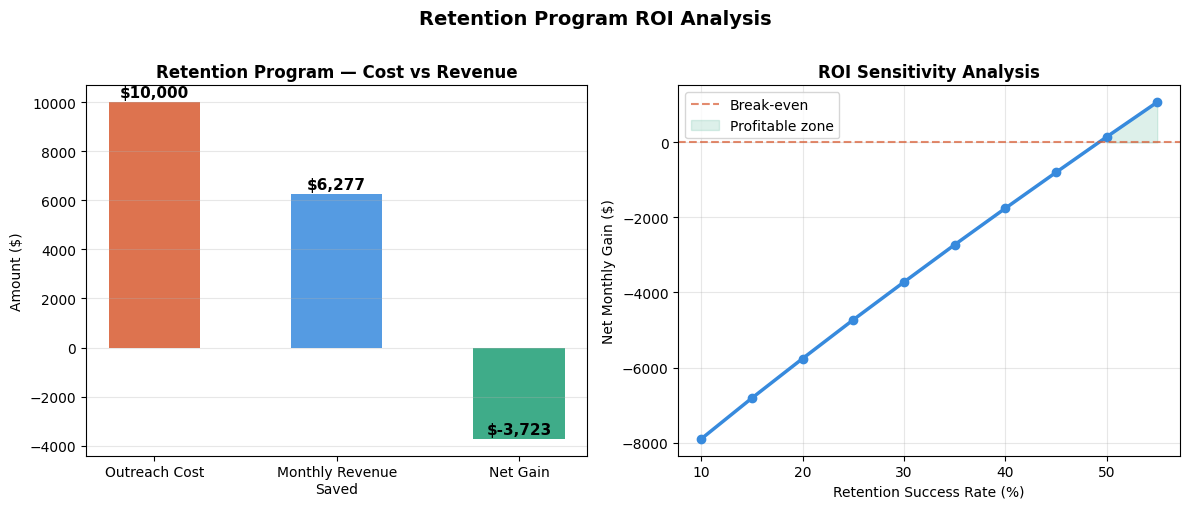

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: Cost vs Revenue saved
categories = ['Outreach Cost', 'Monthly Revenue\nSaved', 'Net Gain']
values      = [total_outreach_cost, monthly_revenue_saved, net_monthly_gain]
bar_colors  = ['#D85A30', '#378ADD', '#1D9E75']

axes[0].bar(categories, values, color=bar_colors, alpha=0.85, width=0.5)
axes[0].set_title('Retention Program — Cost vs Revenue', fontweight='bold')
axes[0].set_ylabel('Amount ($)')
for i, (bar, val) in enumerate(zip(axes[0].patches, values)):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 200,
                 f'${val:,.0f}', ha='center', fontweight='bold', fontsize=11)
axes[0].grid(axis='y', alpha=0.3)

# Right: Sensitivity — what if success rate changes?
success_rates = np.arange(0.10, 0.60, 0.05)
net_gains     = []
for rate in success_rates:
    saved     = int(CONTACT_TOP_N * rate)
    rev_saved = top_n.head(saved)['monthly_charges'].sum()
    net_gains.append(rev_saved - total_outreach_cost)

axes[1].plot(success_rates * 100, net_gains,
             marker='o', color='#378ADD', linewidth=2.5)
axes[1].axhline(y=0, color='#D85A30', linestyle='--',
                alpha=0.7, label='Break-even')
axes[1].fill_between(success_rates * 100, net_gains,
                     where=[g > 0 for g in net_gains],
                     alpha=0.15, color='#1D9E75', label='Profitable zone')
axes[1].set_xlabel('Retention Success Rate (%)')
axes[1].set_ylabel('Net Monthly Gain ($)')
axes[1].set_title('ROI Sensitivity Analysis', fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Retention Program ROI Analysis', fontsize=14,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('charts/15_retention_roi.png', dpi=150)
plt.show()


REVENUE AT RISK BY CONTRACT TYPE
                Customers  Monthly_Rev_At_Risk  Avg_CLV
contract                                               
Month-to-month        461              32929.0    857.0
One year               21               2086.0   1788.0
Two year                1                108.0   3243.0


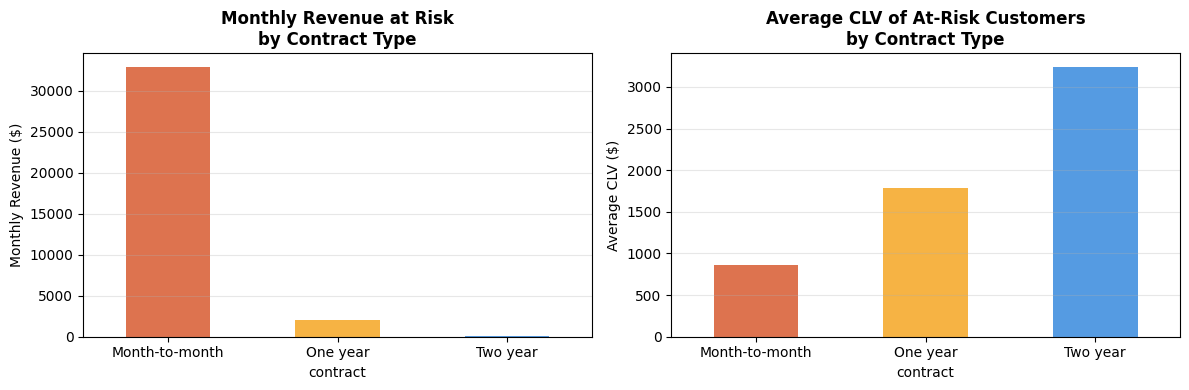

In [9]:
# Revenue at risk by contract type
contract_risk = revenue_df[revenue_df['predicted_churn']==1].groupby('contract').agg(
    Customers          = ('monthly_charges', 'count'),
    Monthly_Rev_At_Risk= ('monthly_charges', 'sum'),
    Avg_CLV            = ('clv', 'mean')
).round(0)

print("\nREVENUE AT RISK BY CONTRACT TYPE")
print(contract_risk.to_string())

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

contract_risk['Monthly_Rev_At_Risk'].plot(
    kind='bar', ax=axes[0], color=['#D85A30','#F5A623','#378ADD'],
    rot=0, alpha=0.85
)
axes[0].set_title('Monthly Revenue at Risk\nby Contract Type', fontweight='bold')
axes[0].set_ylabel('Monthly Revenue ($)')
axes[0].grid(axis='y', alpha=0.3)

contract_risk['Avg_CLV'].plot(
    kind='bar', ax=axes[1], color=['#D85A30','#F5A623','#378ADD'],
    rot=0, alpha=0.85
)
axes[1].set_title('Average CLV of At-Risk Customers\nby Contract Type', fontweight='bold')
axes[1].set_ylabel('Average CLV ($)')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('charts/16_revenue_by_contract.png', dpi=150)
plt.show()

In [10]:
# Save the full at-risk customer list with all metrics
at_risk_ranked.to_csv('data/full_at_risk_customers.csv', index=False)

# Save ROI summary as a dict for the dashboard
roi_summary = {
    'total_customers_scored'     : len(revenue_df),
    'customers_at_risk'          : int(y_pred.sum()),
    'monthly_revenue_at_risk'    : round(monthly_revenue_at_risk, 0),
    'total_clv_at_risk'          : round(total_revenue_at_risk, 0),
    'retention_roi_pct'          : round(roi_pct, 1),
    'monthly_net_gain'           : round(net_monthly_gain, 0),
    'customers_saved_estimate'   : customers_saved
}

import json
with open('data/roi_summary.json', 'w') as f:
    json.dump(roi_summary, f, indent=2)

print("✓ Full at-risk customer list saved")
print("✓ ROI summary saved")
print()
print("FINAL HEADLINE NUMBERS FOR YOUR PORTFOLIO:")
print(f"  💰 Monthly revenue at risk    : ${monthly_revenue_at_risk:,.0f}")
print(f"  📊 Customers identified       : {int(y_pred.sum())}")
print(f"  📈 Retention program ROI      : {roi_pct:.0f}%")
print(f"  💵 Net monthly gain possible  : ${net_monthly_gain:,.0f}")

✓ Full at-risk customer list saved
✓ ROI summary saved

FINAL HEADLINE NUMBERS FOR YOUR PORTFOLIO:
  💰 Monthly revenue at risk    : $35,123
  📊 Customers identified       : 483
  📈 Retention program ROI      : -37%
  💵 Net monthly gain possible  : $-3,723
